# Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import torch.nn as nn

# Configurando a Base de dados

In [2]:
np.random.seed(123)
torch.manual_seed(123) 

In [3]:
df = pd.read_csv('/content/drive/MyDrive/entradas_breast.csv')
classe = pd.read_csv('/content/drive/MyDrive/saidas_breast.csv')

In [4]:
df.shape

(569, 30)

In [5]:
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1095.0000,0.9053,8589.0,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3398.0,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,186.0000,275.0000,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4585.0,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,243.0000,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1156.0000,3445.0,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,173.00000
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,198.0000,0.10430,0.1809,0.05883,0.7572,0.7813,5438.0,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,205.0000,0.4000,0.1625,0.2364,0.07678


In [6]:
classe.shape

(569, 1)

In [7]:
classe.head()

,0
0,0
1,0
2,0
3,0
4,0


In [8]:
np.unique(classe)

array([0, 1])

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


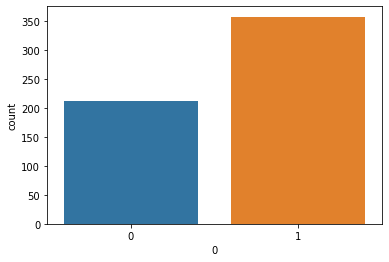

In [9]:
sns.countplot(classe['0']);

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, classe,
                                                    test_size= 0.25)

In [11]:
print('X_train', X_train.shape)
print('y_train', y_train.shape)
print('X_test', X_test.shape)
print('y_test', y_test.shape)

X_train (426, 30)
y_train (426, 1)
X_test (143, 30)
y_test (143, 1)


# Transformando os dados para Tensores.

In [12]:
type(X_train)

pandas.core.frame.DataFrame

In [13]:
type(np.array(X_train))

numpy.ndarray

In [14]:
X_train = torch.tensor(np.array(X_train), dtype=torch.float)
y_train = torch.tensor(np.array(y_train), dtype=torch.float)

In [15]:
type(X_train)

torch.Tensor

In [16]:
type(y_train)

torch.Tensor

In [17]:
data = torch.utils.data.TensorDataset(X_train, y_train)

In [18]:
type(data)

torch.utils.data.dataset.TensorDataset

In [19]:
train_load = torch.utils.data.DataLoader(data, batch_size=10, shuffle=True)

# Construção do Modelo

In [20]:
classificador = nn.Sequential(
    nn.Linear(in_features=30, out_features=16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

In [21]:
classificador.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)>

In [22]:
criterion = nn.BCELoss()

In [23]:
optimizer = torch.optim.Adam(classificador.parameters(), lr=0.001, weight_decay=0.0001)

# Treinamento do Modelo.

In [24]:
for epoch in range(100):
  runnig_loss = 0.

  for datas in train_load:
    inputs, labels = datas
    optimizer.zero_grad()

    outputs = classificador(inputs) 
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    runnig_loss += loss.item()
  print('Época %3d: perda %.5f' %(epoch +1, runnig_loss/len(train_load)))

Época   1: perda 10.78336
Época   2: perda 2.84863
Época   3: perda 1.67480
Época   4: perda 1.11414
Época   5: perda 0.63996
Época   6: perda 0.63753
Época   7: perda 0.58066
Época   8: perda 0.55460
Época   9: perda 0.55617
Época  10: perda 0.53322
Época  11: perda 0.55797
Época  12: perda 0.53816
Época  13: perda 0.52938
Época  14: perda 0.33227
Época  15: perda 0.51360
Época  16: perda 0.35532
Época  17: perda 0.49602
Época  18: perda 0.33208
Época  19: perda 0.29349
Época  20: perda 0.25046
Época  21: perda 0.29527
Época  22: perda 0.49888
Época  23: perda 0.47241
Época  24: perda 0.45883
Época  25: perda 0.27544
Época  26: perda 0.23399
Época  27: perda 0.26373
Época  28: perda 0.24136
Época  29: perda 0.28275
Época  30: perda 0.22633
Época  31: perda 0.19294
Época  32: perda 0.22258
Época  33: perda 0.20290
Época  34: perda 0.20888
Época  35: perda 0.20335
Época  36: perda 0.20316
Época  37: perda 0.18855
Época  38: perda 0.22316
Época  39: perda 0.23315
Época  40: perda 0.19261

# Visualização dos pesos.

In [25]:
parametros = list(classificador.parameters())
parametros

[Parameter containing:
 tensor([[-6.8758e-02, -4.5974e-02, -1.6881e-01,  5.1889e-02, -1.5407e-01,
           9.6941e-02, -1.3697e-01, -1.2676e-01, -2.2155e-01,  1.6481e-01,
          -3.7779e-02,  5.3912e-02, -1.2468e-01, -1.1436e-01, -1.3912e-03,
          -2.1398e-01, -3.9141e-01,  6.5978e-04, -6.6723e-03,  1.4566e-03,
           1.4102e-01, -2.0637e-02, -2.8877e-02,  1.4110e-01,  4.9312e-01,
           1.3069e-01, -1.8659e-01,  4.4318e-02,  2.9165e-01,  3.7982e-02],
         [ 1.9542e-01,  2.0732e-01,  2.8639e-01,  9.7069e-02, -1.3307e-01,
          -8.0457e-02, -6.7914e-02, -1.2084e-01, -2.8640e-02,  2.6983e-01,
          -6.2204e-02, -9.1055e-02, -7.9371e-03,  1.6734e-01, -7.2613e-03,
          -9.6179e-02, -1.1189e-02,  1.8739e-01,  1.0368e-01, -1.7496e-02,
           9.8523e-02,  6.1815e-02,  1.8995e-01,  7.5789e-03, -1.5083e-02,
          -2.4596e-01, -1.7552e-01, -7.0061e-03, -6.5762e-02, -1.6863e-01],
         [-1.2082e-02, -4.2609e-02, -2.4278e-01, -1.0345e-01, -8.2591e-03,


In [26]:
peso_0 = parametros[0]
peso_0.shape

torch.Size([16, 30])

In [27]:
print(peso_0)

Parameter containing:
tensor([[-6.8758e-02, -4.5974e-02, -1.6881e-01,  5.1889e-02, -1.5407e-01,
          9.6941e-02, -1.3697e-01, -1.2676e-01, -2.2155e-01,  1.6481e-01,
         -3.7779e-02,  5.3912e-02, -1.2468e-01, -1.1436e-01, -1.3912e-03,
         -2.1398e-01, -3.9141e-01,  6.5978e-04, -6.6723e-03,  1.4566e-03,
          1.4102e-01, -2.0637e-02, -2.8877e-02,  1.4110e-01,  4.9312e-01,
          1.3069e-01, -1.8659e-01,  4.4318e-02,  2.9165e-01,  3.7982e-02],
        [ 1.9542e-01,  2.0732e-01,  2.8639e-01,  9.7069e-02, -1.3307e-01,
         -8.0457e-02, -6.7914e-02, -1.2084e-01, -2.8640e-02,  2.6983e-01,
         -6.2204e-02, -9.1055e-02, -7.9371e-03,  1.6734e-01, -7.2613e-03,
         -9.6179e-02, -1.1189e-02,  1.8739e-01,  1.0368e-01, -1.7496e-02,
          9.8523e-02,  6.1815e-02,  1.8995e-01,  7.5789e-03, -1.5083e-02,
         -2.4596e-01, -1.7552e-01, -7.0061e-03, -6.5762e-02, -1.6863e-01],
        [-1.2082e-02, -4.2609e-02, -2.4278e-01, -1.0345e-01, -8.2591e-03,
          4.95

In [28]:
bias_0 = parametros[1]
bias_0.shape

torch.Size([16])

In [29]:
peso1 = parametros[2]
peso1.shape

torch.Size([16, 16])

# Avaliação do Modelo.

In [30]:
classificador.eval()

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

In [31]:
type(X_test)

pandas.core.frame.DataFrame

In [32]:
previsores = torch.tensor(np.array(X_test), dtype= torch.float)

In [33]:
type(X_test)

pandas.core.frame.DataFrame

In [34]:
resultados = classificador(previsores)  

In [35]:
resultados


tensor([[9.9383e-01],
        [1.0000e+00],
        [3.1412e-01],
        [9.4383e-01],
        [1.3290e-04],
        [8.4746e-01],
        [9.4431e-01],
        [9.9988e-01],
        [6.2488e-01],
        [6.5691e-01],
        [9.1439e-01],
        [9.9876e-01],
        [6.7283e-01],
        [9.9518e-01],
        [9.9706e-01],
        [8.6089e-01],
        [9.9605e-01],
        [1.0000e+00],
        [2.9267e-01],
        [9.9612e-01],
        [7.4813e-10],
        [1.0656e-02],
        [5.8519e-01],
        [1.0000e+00],
        [9.0273e-01],
        [4.2905e-03],
        [8.2606e-01],
        [1.0000e+00],
        [1.8561e-04],
        [9.9753e-01],
        [5.3080e-01],
        [9.9999e-01],
        [9.2115e-01],
        [9.8746e-01],
        [4.5453e-01],
        [9.9757e-01],
        [6.0572e-01],
        [9.9787e-01],
        [9.9748e-01],
        [4.9014e-05],
        [6.0460e-03],
        [9.2253e-01],
        [1.5413e-07],
        [4.1097e-01],
        [7.4316e-05],
        [7

In [36]:
resultados = np.array(resultados > 0.5)
resultados

array([[ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
taxa_de_acertos = accuracy_score(y_test, resultados)
taxa_de_acertos

0.9020979020979021

In [39]:
from sklearn.metrics import confusion_matrix

In [40]:
matriz = confusion_matrix(y_test, resultados)
matriz

array([[43, 11],
       [ 3, 86]])

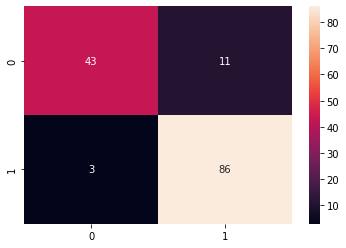

In [41]:
sns.heatmap(matriz, annot=True);